# 01 — Data Audit & Exploratory Analysis

**Objective:** understand the dataset, class imbalance, data quality, and the differences between fraudulent and legitimate transactions before any modeling.

Dataset: Kaggle "Credit Card Transactions Fraud Detection Dataset" (Sparkov-generated), `fraudTrain.csv` + `fraudTest.csv`, already split by Kaggle along time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

DATA_DIR = '../data'

## Load data

In [2]:
train = pd.read_csv(f'{DATA_DIR}/fraudTrain.csv', index_col=0)
test = pd.read_csv(f'{DATA_DIR}/fraudTest.csv', index_col=0)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head(3)

Train shape: (1296675, 22)
Test shape: (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [3]:
train.dtypes

trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

## Class imbalance

In [4]:
for name, df in [('train', train), ('test', test)]:
    n = len(df)
    n_fraud = df['is_fraud'].sum()
    pct = 100 * n_fraud / n
    ratio = n / n_fraud
    print(f'{name}: {n:,} transactions, {n_fraud:,} fraud ({pct:.3f}%), imbalance ratio ~1:{ratio:.0f}')

train: 1,296,675 transactions, 7,506 fraud (0.579%), imbalance ratio ~1:173
test: 555,719 transactions, 2,145 fraud (0.386%), imbalance ratio ~1:259


## Missing values & duplicates

In [5]:
print('Missing values per column (train):')
missing = train.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None')

print('\nExact duplicate rows (train):', train.duplicated().sum())
print('Duplicate trans_num (train):', train['trans_num'].duplicated().sum())

Missing values per column (train):
None



Exact duplicate rows (train): 0
Duplicate trans_num (train): 0


## Transaction amount distribution

In [6]:
print(train['amt'].describe())
print()
print('Amount by class:')
print(train.groupby('is_fraud')['amt'].describe()[['mean', '50%', 'std', 'min', 'max']])

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

Amount by class:


                mean      50%         std   min       max
is_fraud                                                 
0          67.667110   47.280  154.007971  1.00  28948.90
1         531.320092  396.505  390.560070  1.06   1376.04


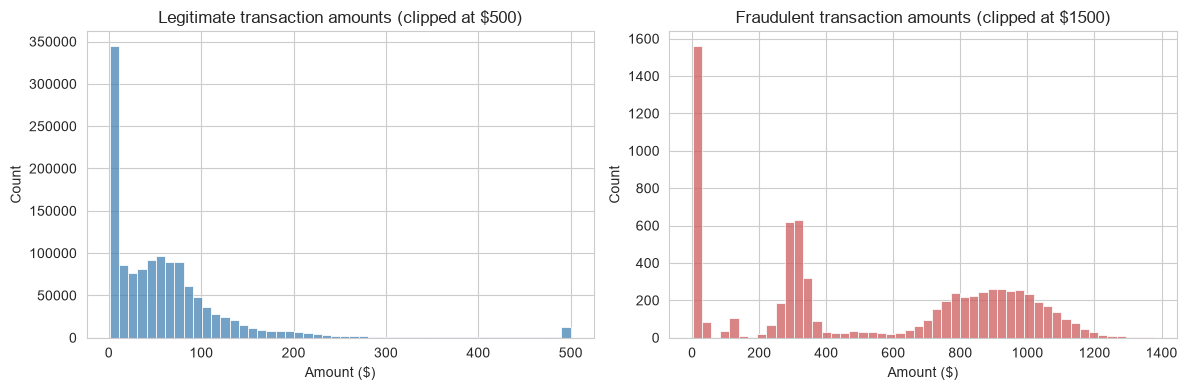

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train.loc[train['is_fraud'] == 0, 'amt'].clip(upper=500), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate transaction amounts (clipped at $500)')
axes[0].set_xlabel('Amount ($)')

sns.histplot(train.loc[train['is_fraud'] == 1, 'amt'].clip(upper=1500), bins=50, ax=axes[1], color='indianred')
axes[1].set_title('Fraudulent transaction amounts (clipped at $1500)')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

## Fraud rate across amount ranges

In [8]:
bins = [0, 10, 25, 50, 100, 250, 500, 1000, np.inf]
labels = ['0-10', '10-25', '25-50', '50-100', '100-250', '250-500', '500-1000', '1000+']
train['amt_bin'] = pd.cut(train['amt'], bins=bins, labels=labels)

fraud_by_amt = train.groupby('amt_bin')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_amt.columns = ['n_transactions', 'n_fraud', 'fraud_rate']
fraud_by_amt['fraud_rate_pct'] = (fraud_by_amt['fraud_rate'] * 100).round(3)
fraud_by_amt

,n_transactions,n_fraud,fraud_rate,fraud_rate_pct
amt_bin,,,,
0-10,335929,525,0.001563,0.156
10-25,127627,1027,0.008047,0.805
25-50,208743,55,0.000263,0.026
50-100,389483,45,0.000116,0.012
100-250,196435,244,0.001242,0.124
250-500,22827,1962,0.085951,8.595
500-1000,11695,2699,0.230782,23.078
1000+,3936,949,0.241108,24.111


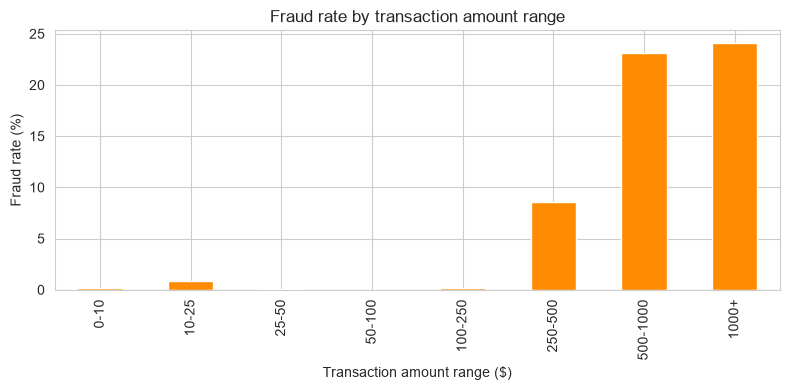

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
fraud_by_amt['fraud_rate_pct'].plot(kind='bar', ax=ax, color='darkorange')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlabel('Transaction amount range ($)')
ax.set_title('Fraud rate by transaction amount range')
plt.tight_layout()
plt.show()

## Temporal fraud patterns

In [10]:
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
train['hour'] = train['trans_date_trans_time'].dt.hour
train['day_of_week'] = train['trans_date_trans_time'].dt.day_name()

print('Date range (train):', train['trans_date_trans_time'].min(), '->', train['trans_date_trans_time'].max())

Date range (train): 2019-01-01 00:00:18 -> 2020-06-21 12:13:37


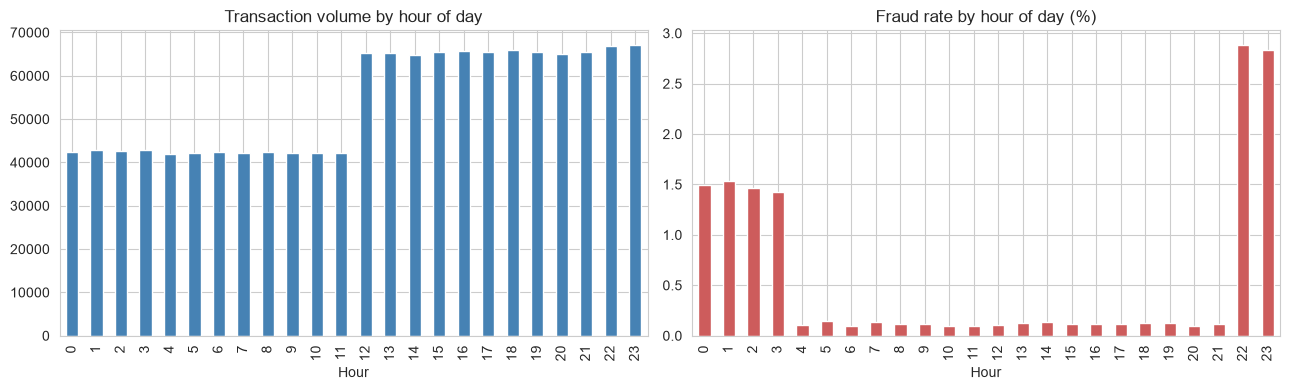

In [11]:
fraud_by_hour = train.groupby('hour')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_hour.columns = ['n_transactions', 'n_fraud', 'fraud_rate']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fraud_by_hour['n_transactions'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transaction volume by hour of day')
axes[0].set_xlabel('Hour')

(fraud_by_hour['fraud_rate'] * 100).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Fraud rate by hour of day (%)')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

In [12]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_dow = train.groupby('day_of_week')['is_fraud'].agg(['count', 'sum', 'mean']).reindex(dow_order)
fraud_by_dow.columns = ['n_transactions', 'n_fraud', 'fraud_rate']
fraud_by_dow['fraud_rate_pct'] = (fraud_by_dow['fraud_rate'] * 100).round(3)
fraud_by_dow

,n_transactions,n_fraud,fraud_rate,fraud_rate_pct
day_of_week,,,,
Monday,254282,1182,0.004648,0.465
Tuesday,160227,935,0.005835,0.584
Wednesday,131073,859,0.006554,0.655
Thursday,147285,1008,0.006844,0.684
Friday,152272,1079,0.007086,0.709
Saturday,200957,1227,0.006106,0.611
Sunday,250579,1216,0.004853,0.485


**Observation:** fraud is disproportionately concentrated in late-night/early-morning hours relative to overall transaction volume, which is much lower at those hours — a clue that fraud doesn't just follow the volume curve. This motivates an hour-of-day feature in later stages.

## Category, demographic, and geographic patterns

In [13]:
fraud_by_cat = train.groupby('category')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_cat.columns = ['n_transactions', 'n_fraud', 'fraud_rate']
fraud_by_cat['fraud_rate_pct'] = (fraud_by_cat['fraud_rate'] * 100).round(3)
fraud_by_cat.sort_values('fraud_rate_pct', ascending=False)

,n_transactions,n_fraud,fraud_rate,fraud_rate_pct
category,,,,
shopping_net,97543,1713,0.017561,1.756
misc_net,63287,915,0.014458,1.446
grocery_pos,123638,1743,0.014098,1.410
shopping_pos,116672,843,0.007225,0.723
gas_transport,131659,618,0.004694,0.469
misc_pos,79655,250,0.003139,0.314
grocery_net,45452,134,0.002948,0.295
travel,40507,116,0.002864,0.286
entertainment,94014,233,0.002478,0.248


In [14]:
train['dob'] = pd.to_datetime(train['dob'])
train['age'] = (train['trans_date_trans_time'] - train['dob']).dt.days // 365

age_bins = [0, 25, 35, 45, 55, 65, 75, np.inf]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
train['age_bin'] = pd.cut(train['age'], bins=age_bins, labels=age_labels)

fraud_by_age = train.groupby('age_bin')['is_fraud'].agg(['count', 'sum', 'mean'])
fraud_by_age.columns = ['n_transactions', 'n_fraud', 'fraud_rate']
fraud_by_age['fraud_rate_pct'] = (fraud_by_age['fraud_rate'] * 100).round(3)
fraud_by_age

,n_transactions,n_fraud,fraud_rate,fraud_rate_pct
age_bin,,,,
<25,144604,895,0.006189,0.619
25-34,299697,1417,0.004728,0.473
35-44,266603,1146,0.004299,0.430
45-54,242995,1426,0.005868,0.587
55-64,163684,1244,0.007600,0.760
65-74,90381,562,0.006218,0.622
75+,88711,816,0.009198,0.920


In [15]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

train['merchant_distance_km'] = haversine_km(train['lat'], train['long'], train['merch_lat'], train['merch_long'])

print(train.groupby('is_fraud')['merchant_distance_km'].describe()[['mean', '50%', 'std', 'max']])

               mean        50%        std         max
is_fraud                                             
0         76.113756  78.233012  29.119051  152.117173
1         76.268330  77.931954  28.752602  144.522410


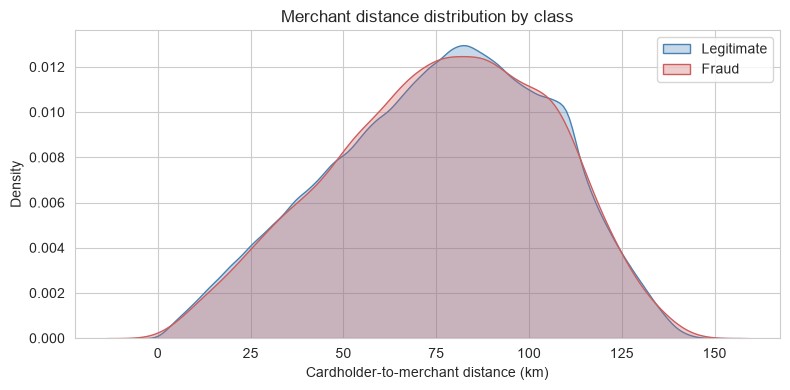

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(train.loc[train['is_fraud'] == 0, 'merchant_distance_km'], ax=ax, label='Legitimate', color='steelblue', fill=True, alpha=0.3)
sns.kdeplot(train.loc[train['is_fraud'] == 1, 'merchant_distance_km'], ax=ax, label='Fraud', color='indianred', fill=True, alpha=0.3)
ax.set_xlabel('Cardholder-to-merchant distance (km)')
ax.set_title('Merchant distance distribution by class')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** category and age show real (if modest) separation — fraud rate ranges from ~0.16% in `health_fitness` up to ~1.76% in `shopping_net`, and rises for both the youngest and 75+ age groups. Merchant distance, on the other hand, shows essentially **no** separation (mean ~76 km for both fraud and legitimate transactions) — this generator doesn't encode 'far from home' as a fraud signal the way real-world card-not-present fraud often does. No single feature cleanly separates the classes, consistent with fraud being a rare, multi-factor pattern rather than a simple threshold rule on any one field. This is exactly why a model benchmarked on the right metrics (Stage 4) is needed, rather than hand-written rules alone — and it's a limitation worth noting for Stage 9 (fraud rules), where a geographic-anomaly rule would likely add little on this dataset.

## Key Question: why is accuracy misleading here?

In [17]:
n = len(train)
n_fraud = train['is_fraud'].sum()
naive_accuracy = (n - n_fraud) / n

print(f"A classifier that predicts 'legitimate' for every single transaction achieves "
      f"{naive_accuracy * 100:.3f}% accuracy on this training set, while catching 0% of fraud.")

A classifier that predicts 'legitimate' for every single transaction achieves 99.421% accuracy on this training set, while catching 0% of fraud.


With fraud at well under 1% of transactions, a trivial always-legitimate model scores above 99% accuracy while being operationally useless — it catches no fraud at all. Accuracy is dominated by the majority (legitimate) class and says nothing about whether fraud is being caught. This is why the rest of this project reports precision, recall, F1, PR-AUC, and false-positive rate instead of accuracy (Stages 3+).

## Summary of EDA findings

- Severe class imbalance (~1:150-1:200 fraud-to-legitimate), consistent between train and test splits.
- No missing values; no duplicate `trans_num`s.
- Fraud skews toward higher transaction amounts than typical legitimate transactions, but with heavy overlap — amount alone isn't a clean separator.
- Fraud rate varies meaningfully by hour of day, transaction category, cardholder age, and cardholder-to-merchant distance — all candidate features for Stage 2's preprocessing pipeline.
- Accuracy is not a usable success metric given the class imbalance; fraud-specific metrics (precision, recall, F1, PR-AUC, FPR) are required from Stage 3 onward.
- Real timestamps are available and span a multi-month period, supporting a temporal train/validation split in Stage 2 rather than a random stratified split.

## Train / Validation / Test Split Strategy (Stage 2)

fraudTest.csv is not a random sample - its timestamps run 2020-06-21 through 2020-12-31, picking up exactly where fraudTrain.csv leaves off (2019-01-01 through 2020-06-21). Kaggle already gave us a clean temporal train/test split. We keep it as-is: **fraudTest.csv is held out untouched until final evaluation.**

For a validation set (needed for threshold selection and model comparison before touching the real test set), we carve the **last 6 weeks of the train period** off as validation, using only the train file - never touching fraudTest.csv early. This mirrors a real deployment: train on history, validate on the most recent few weeks, then confirm on genuinely future data.

This logic lives in `src/preprocessing.py` (`engineer_features`, `temporal_train_val_split`, `build_preprocessor`), so every later stage reuses the same split and feature engineering instead of re-deriving it.

In [18]:
import sys
sys.path.insert(0, '../src')
import preprocessing as pp

train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
test_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTest.csv'))

train_split, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

for name, d in [('train', train_split), ('val', val_split), ('test', test_raw)]:
    print(f"{name:5s}: {d['trans_date_trans_time'].min()} -> {d['trans_date_trans_time'].max()}  "
          f"n={len(d):,}  fraud_rate={100 * d['is_fraud'].mean():.3f}%")

X_train, y_train = pp.split_X_y(train_split)
preprocessor = pp.build_preprocessor()
Xt_train = preprocessor.fit_transform(X_train)
print('\nTransformed train feature matrix shape:', Xt_train.shape)

train: 2019-01-01 00:00:18 -> 2020-05-10 12:13:21  n=1,185,094  fraud_rate=0.577%
val  : 2020-05-10 12:13:54 -> 2020-06-21 12:13:37  n=111,581  fraud_rate=0.600%
test : 2020-06-21 12:14:25 -> 2020-12-31 23:59:34  n=555,719  fraud_rate=0.386%



Transformed train feature matrix shape: (1185094, 28)
